In [1]:
%matplotlib inline

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import biobalm
os.chdir('../../')
import valley

plt.rcParams["figure.dpi"] = 110

BNET_PATH = "model/Autophagy_and_apoptosis_Sept26.bnet"
FIGURE_DIR = "figures"
LAYOUT = "kamada_kawai"   # shared by every network figure below
SEED = 0


model = valley.read_bnet(BNET_PATH)
print(f"{len(model.nodes)} nodes loaded from {BNET_PATH}")

119 nodes loaded from model/Autophagy_and_apoptosis_Sept26.bnet


## Step 1 — The influence graph

Draw the model structure and check the edge signs first. A high **dual** fraction means the
`.bnet` sign heuristic is failing on this file's syntax, and no structural distance should be
trusted until that is fixed.

The layout computed here is reused by every later network figure, so panels stay comparable.

119 nodes, 199 edges
activation 118 | inhibition 52 | dual 29 (15% dual)


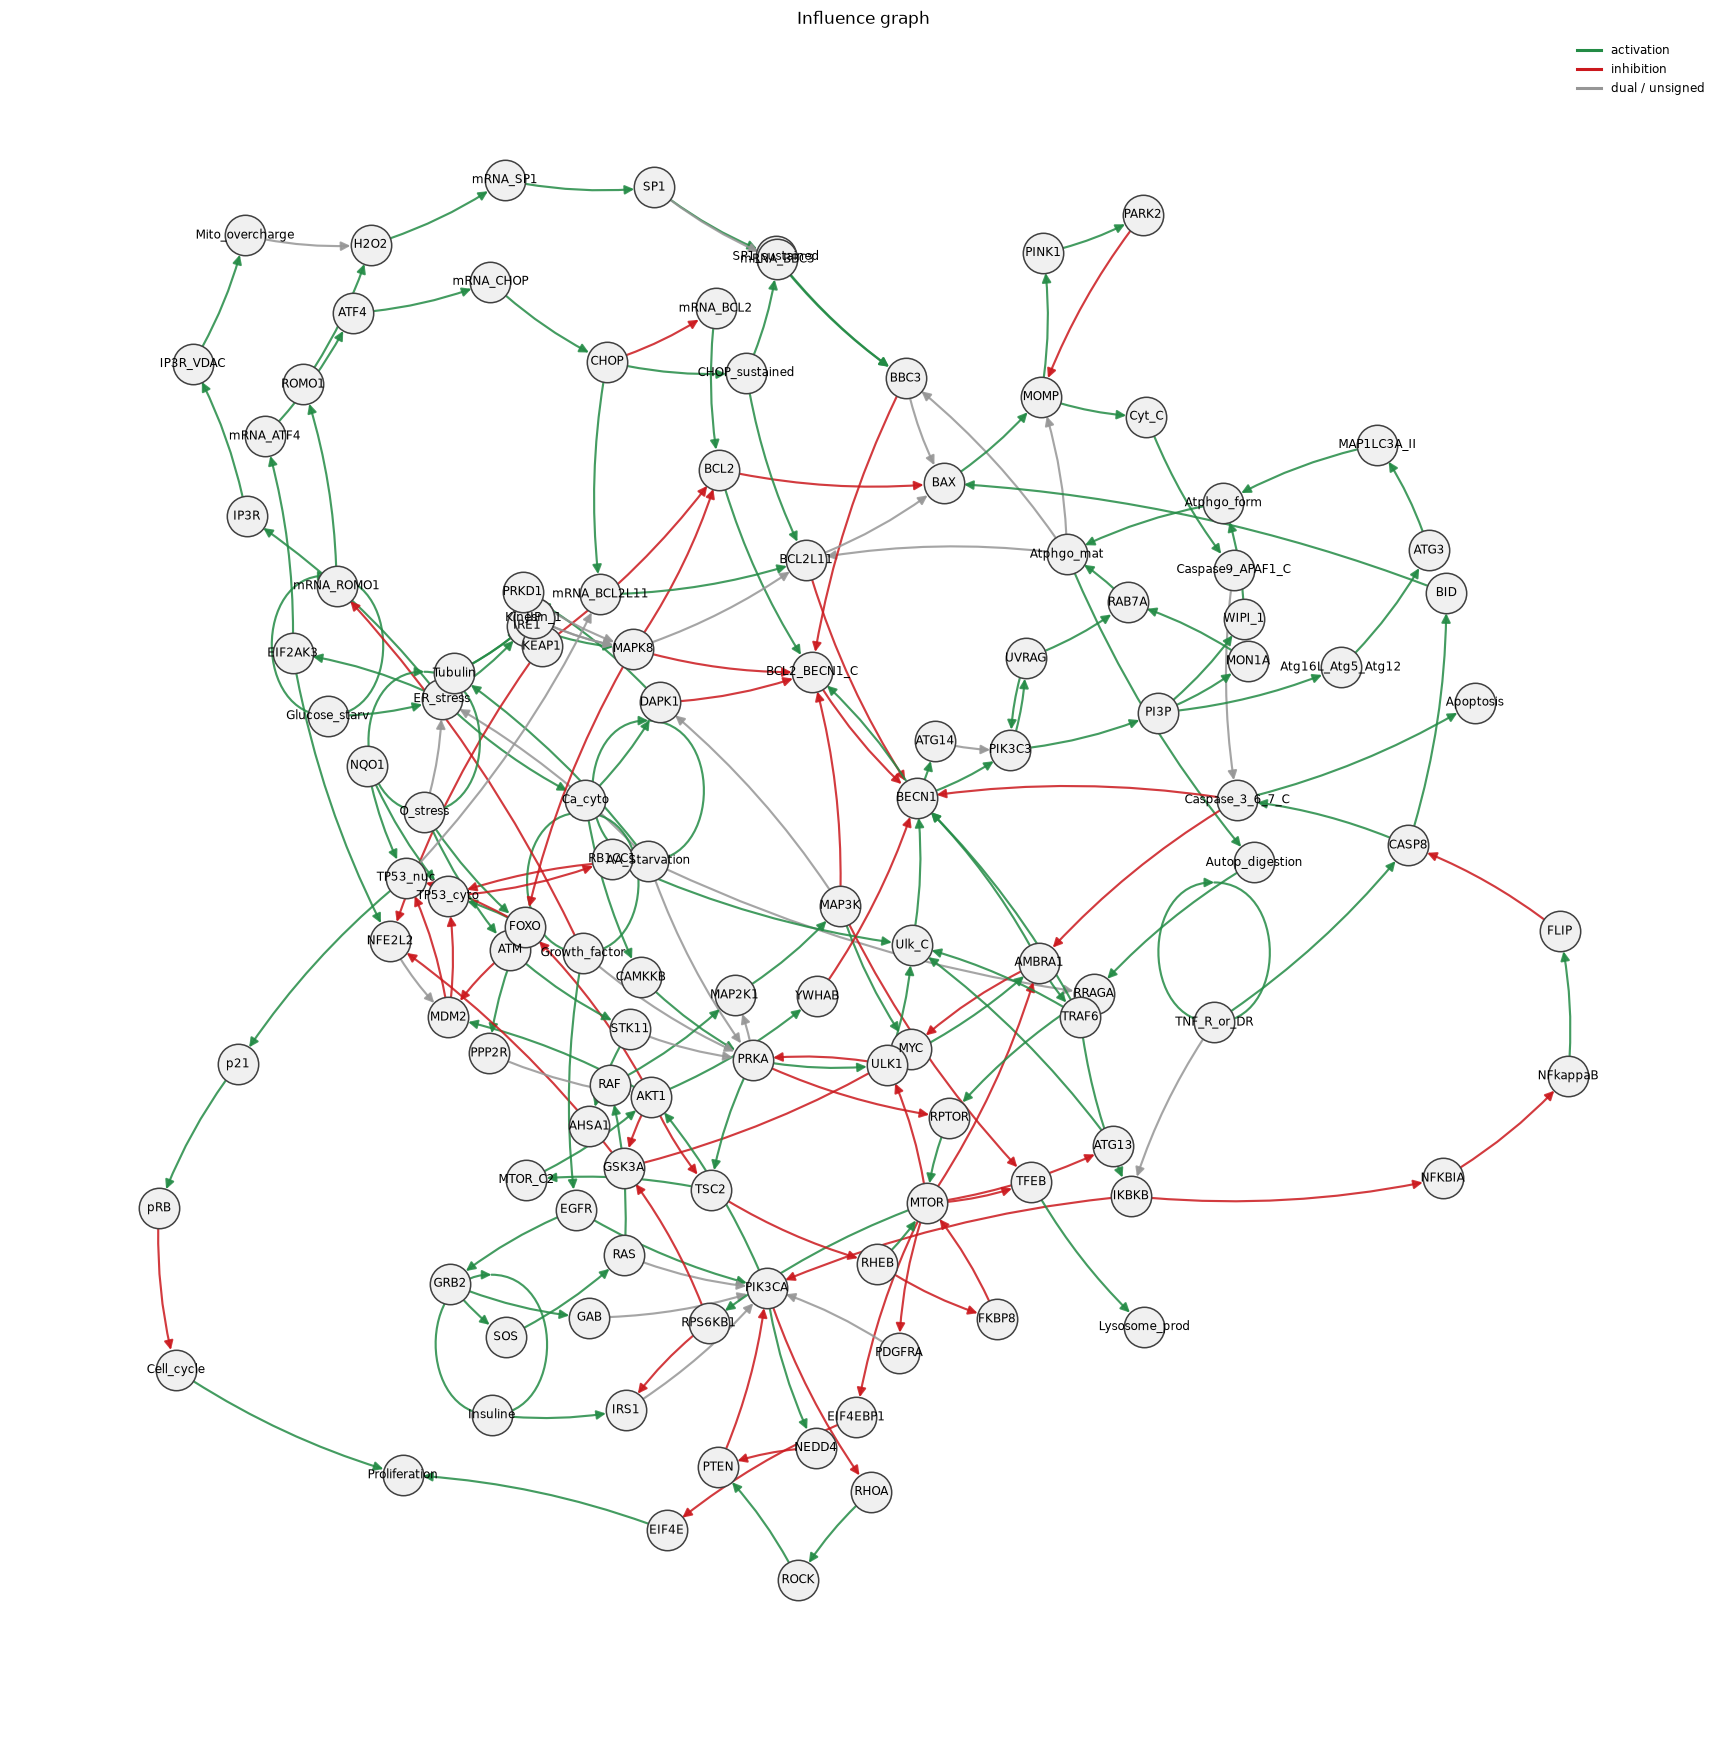

In [2]:
G = valley.influence_graph(model)
positions = valley.layout_positions(G, layout=LAYOUT, seed=SEED)

signs = np.array([data["sign"] for _, _, data in G.edges(data=True)])
print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
if signs.size:
    print(
        "activation {} | inhibition {} | dual {} ({:.0%} dual)".format(
            int((signs > 0).sum()),
            int((signs < 0).sum()),
            int((signs == 0).sum()),
            float((signs == 0).mean()),
        )
    )

ax = valley.plot_influence_graph(
    G,
    positions=positions,
    node_size=700,
    edge_width=1.4,
    font_size=8,
    title="Influence graph",
    figsize=(20,20)
)

## Step 2 — The attractor set

Computing attractors is out of scope for `valley`; this step only loads them. Produce the table
with `biobalm` on the same `.bnet` file and write it as **one row per attractor, one column per
node**, values in $\{0, 1\}$ — or a mean activity per node for a cyclic attractor. Anything that
yields that table works: `biobalm`, `pystablemotifs`, MaBoSS fixed points.

`state_matrix` aligns the columns to `model.nodes` and fills any missing node with 0, so the
report below flags what was dropped.

/Users/saran/miniconda3/envs/valley/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/saran/miniconda3/envs/valley/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


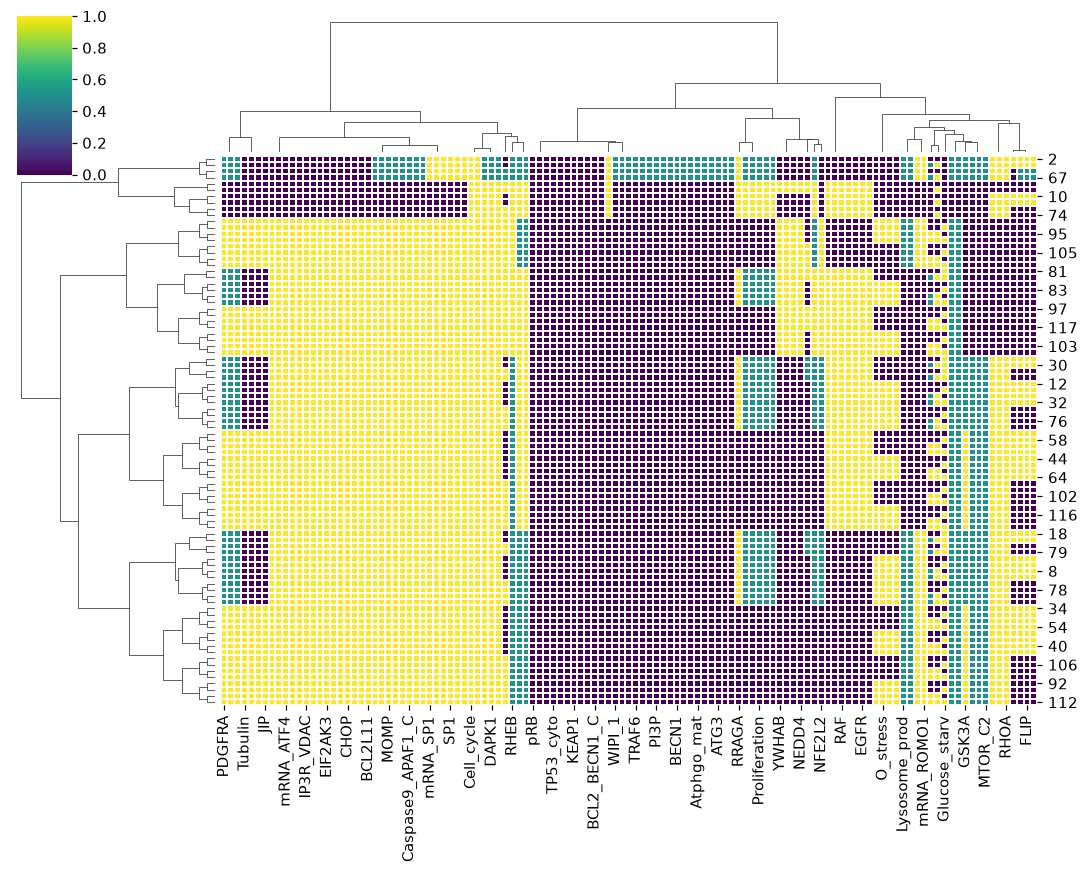

In [3]:
# Load the model
sd = biobalm.SuccessionDiagram.from_file(BNET_PATH)

# Build the succession diagram
sd.build() 
sd.summary()

# Save the succession diagram to a network object
G = sd.dag

# Convert the succession diagram DAG to a DataFrame for analysis
node_list = sd.network.variable_names()
data = sd.dag.nodes(data=True)
indexes_sorted = []
index_list = []
# Extract states from GM nodes and append attractor tag
for _, data in sd.dag.nodes(data=True):
    if 'space' not in data:
        continue

    index = data['space']
    # Reorder `index` to follow the order in `node_list`
    index = {k: index.get(k, '*') for k in node_list}

    # Check whether the node is an attractor candidate and assign tag accordingly
    obj = data.get('attractor_candidates')
    index['tag'] = 't' if obj is None else 'a'

    # Add model tag back to the node data for later use
    index_string = ''.join(str(index.get(k, '*')) for k in node_list + ['tag'])
    sd.dag.nodes[_]['index'] = index_string

    # Compile the index list
    indexes_sorted.append(index)

    # Check index list
    index_list.append(index_string)

# Create a DataFrame from the sorted indexes
sd_states = pd.DataFrame(indexes_sorted)

# Filter the DataFrame to only include attractor states
attractor_states = sd_states.loc[sd_states['tag'] == 'a']
attractor_states = attractor_states.drop(columns=['tag']).replace('*',0.5).astype(float)

sns.clustermap(attractor_states, method='ward', metric='euclidean', cmap='viridis', linewidths=0.1, figsize=(10, 8))

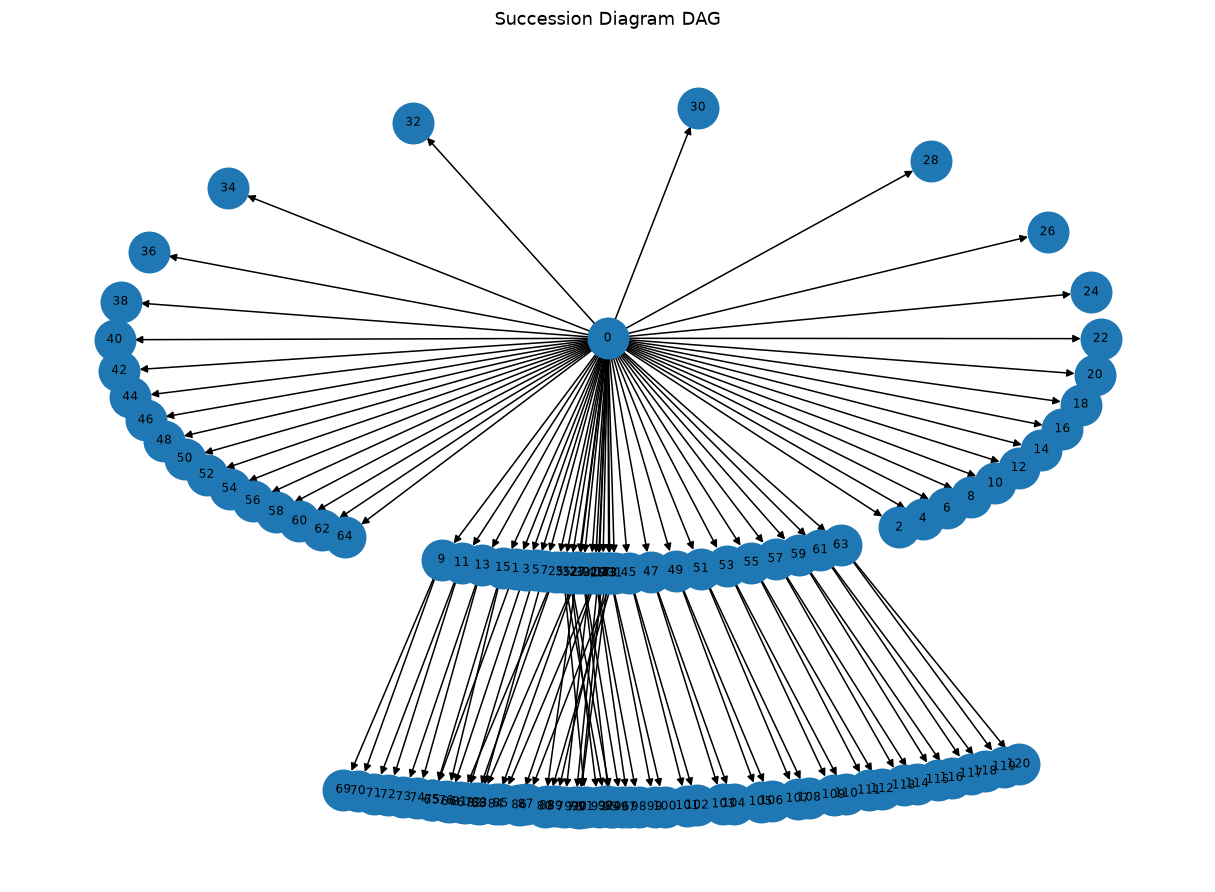

In [116]:
import networkx as nx

# Plot the DAG using a spring layout
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)

pos = nx.kamada_kawai_layout(G)

nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=700,
    font_size=8,
    arrows=True,
)

plt.title("Succession Diagram DAG")
plt.axis("off")
plt.show()


In [5]:
attractors = attractor_states
S, labels = valley.state_matrix(attractors, model)

dropped = sorted(set(model.nodes) - set(map(str, attractors.columns)))
print(f"{S.shape[0]} attractors over {S.shape[1]} model nodes")
if dropped:
    print(f"{len(dropped)} node(s) absent from the table, filled with 0: {dropped[:8]}")
print(f"fractional activities present: {bool(np.any((S > 0) & (S < 1)))}")

88 attractors over 119 model nodes
fractional activities present: True


## Step 3 — Distance matrices and their quality

Build the graph geometry once: the Laplacian is eigendecomposed a single time and reused by every
heat-kernel distance and by the kernel-PCA embedding.

The **same `t` grid** is passed to `build_distance_matrices` and to `sweep_t`. Without that, the
`heat_kernel:t=...` key chosen from the sweep would not exist among the matrices, since the two
functions request different numbers of grid points by default.

In [6]:
geometry = valley.load_geometry(model)
t_values = geometry.suggest_t_grid()

In [7]:
matrices = valley.build_distance_matrices(attractors, model, t_values=t_values)
summary = valley.compare_matrices(matrices)
crosscorr = valley.cross_correlation(matrices)
t_sweep = valley.sweep_t(attractors, model, t_values=t_values)

print(f"{len(matrices)} candidate distances")
summary.round(3)

15 candidate distances


,mean,cv,n_distinct,spearman_vs_ref,pearson_vs_ref
approach,,,,,
reference_axis,1.690,0.910,185,0.617,0.742
heat_kernel:t=280.1,0.770,1.155,721,0.624,0.795
heat_kernel:t=62.33,0.940,0.943,2258,0.752,0.841
heat_kernel:t=13.87,2.069,0.516,2256,0.897,0.930
module_scc,3.945,0.372,800,0.918,0.934
heat_kernel:t=3.086,3.117,0.402,2252,0.925,0.950
weighted_hamming:betweenness,23.450,0.652,541,0.961,0.967
heat_kernel:t=0.6866,3.959,0.352,2240,0.975,0.977
weighted_hamming:degree,25.203,0.644,344,0.987,0.994


The `t` sweep: how the heat-kernel distance departs from Hamming as diffusion time grows.

### Quality report

Three failure modes worth catching before choosing a distance:

- a **degenerate** matrix, where every attractor pair is equally far apart;
- a heat kernel that **tracks Hamming at every `t`**, meaning no structural information was added;
- **redundant** distances, which would waste panels in the collage below.

In [8]:
degenerate = summary.index[summary["n_distinct"] <= 1].tolist()
if degenerate:
    print(f"[warn] degenerate, all pairs equal: {degenerate}")

informative = t_sweep["spearman_vs_hamming"].min()
if informative > 0.95:
    print(
        "[warn] heat kernel tracks Hamming at every t "
        f"(min spearman {informative:.3f}); no structural information added"
    )

redundant = [
    (a, b)
    for i, a in enumerate(crosscorr.index)
    for b in crosscorr.index[i + 1:]
    if crosscorr.loc[a, b] > 0.98
]
print(f"{len(redundant)} redundant pair(s) at spearman > 0.98")
for a, b in redundant[:10]:
    print(f"    {a}  ~  {b}")

crosscorr.round(2)

25 redundant pair(s) at spearman > 0.98
    hamming  ~  weighted_hamming:degree
    hamming  ~  weighted_hamming:pagerank
    hamming  ~  heat_kernel:t=0.001683
    hamming  ~  heat_kernel:t=0.007563
    hamming  ~  heat_kernel:t=0.03399
    hamming  ~  heat_kernel:t=0.1528
    weighted_hamming:degree  ~  weighted_hamming:betweenness
    weighted_hamming:degree  ~  weighted_hamming:pagerank
    weighted_hamming:degree  ~  heat_kernel:t=0.001683
    weighted_hamming:degree  ~  heat_kernel:t=0.007563


,hamming,weighted_hamming:degree,weighted_hamming:betweenness,weighted_hamming:pagerank,heat_kernel:t=0.001683,heat_kernel:t=0.007563,heat_kernel:t=0.03399,heat_kernel:t=0.1528,heat_kernel:t=0.6866,heat_kernel:t=3.086,heat_kernel:t=13.87,heat_kernel:t=62.33,heat_kernel:t=280.1,module_scc,reference_axis
hamming,1.00,0.99,0.96,1.00,1.00,1.00,1.00,0.99,0.98,0.92,0.90,0.75,0.62,0.92,0.62
weighted_hamming:degree,0.99,1.00,0.99,1.00,0.98,0.98,0.98,0.97,0.93,0.86,0.83,0.71,0.59,0.86,0.59
weighted_hamming:betweenness,0.96,0.99,1.00,0.98,0.96,0.96,0.95,0.94,0.89,0.81,0.77,0.66,0.56,0.80,0.56
weighted_hamming:pagerank,1.00,1.00,0.98,1.00,0.99,0.99,0.99,0.99,0.96,0.90,0.88,0.74,0.62,0.90,0.61
heat_kernel:t=0.001683,1.00,0.98,0.96,0.99,1.00,1.00,1.00,1.00,0.98,0.92,0.89,0.75,0.63,0.92,0.61
heat_kernel:t=0.007563,1.00,0.98,0.96,0.99,1.00,1.00,1.00,1.00,0.98,0.92,0.89,0.75,0.63,0.92,0.61
heat_kernel:t=0.03399,1.00,0.98,0.95,0.99,1.00,1.00,1.00,1.00,0.98,0.93,0.89,0.75,0.63,0.92,0.61
heat_kernel:t=0.1528,0.99,0.97,0.94,0.99,1.00,1.00,1.00,1.00,0.99,0.94,0.91,0.77,0.64,0.94,0.62
heat_kernel:t=0.6866,0.98,0.93,0.89,0.96,0.98,0.98,0.98,0.99,1.00,0.98,0.96,0.81,0.67,0.98,0.65
heat_kernel:t=3.086,0.92,0.86,0.81,0.90,0.92,0.92,0.93,0.94,0.98,1.00,0.99,0.84,0.69,0.99,0.66


### Picking one distance

An explicit rule rather than a default: among the `t` values whose matrix still distinguishes
attractor pairs, take the one with the **lowest rank correlation to Hamming** — the scale that
adds the most structural information. Fall back to Hamming if none qualifies.

In [34]:
usable = t_sweep[t_sweep["n_distinct"] > 1].dropna(subset=["spearman_vs_hamming"])

if usable.empty:
    key, t = "hamming", None
    print("no informative heat-kernel scale; falling back to Hamming")
else:
    row = usable.sort_values("spearman_vs_hamming").iloc[0]
    t = float(row["t"])
    key = f"heat_kernel:t={t:.4g}"
    if key not in matrices:
        key, t = "hamming", None
        print("chosen key missing from the matrices; falling back to Hamming")

D = matrices[key]
print(f"chosen distance: {key}")

chosen distance: heat_kernel:t=280.1


## Step 4 — One distance, every embedding

`compare_embeddings` runs all available methods on the same distance and scores each one.
`heat_kernel_pca` is only built when `t` is known, since it works from the state matrix and the
geometry rather than from `D`.

Read the scores before the figure: **stress** and **Spearman fidelity** say whether the picture is
faithful, **trustworthiness** whether local neighbourhoods survive, **silhouette** whether
phenotype labels separate.

In [10]:
result = valley.compare_embeddings(
    D,
    n_components=2,
    S=S if t is not None else None,
    geometry=geometry if t is not None else None,
    t=t,
)
embeddings = result["embeddings"]
print("built:", list(embeddings))

result["scores"].round(3)

/Users/saran/miniconda3/envs/valley/lib/python3.12/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/saran/miniconda3/envs/valley/lib/python3.12/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/saran/miniconda3/envs/valley/lib/python3.12/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
/Users/saran/miniconda3/envs/valley/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/saran/miniconda3/envs/valley/lib/pyt

    SGD-MDS may not have converged: stress changed by -3.2% in final iterations. Consider increasing n_iter or adjusting learning_rate.
built: ['classical_mds', 'nonmetric_mds', 'heat_kernel_pca', 'umap', 'phate', 'tsne', 'force_directed']


,n_components,deterministic,stress,spearman_vs_distance,trustworthiness
embedding,,,,,
heat_kernel_pca,2,True,0.000,1.000,0.998
classical_mds,2,True,0.000,1.000,0.998
nonmetric_mds,2,False,0.028,0.998,0.994
force_directed,2,False,0.584,0.816,0.975
tsne,2,False,0.600,0.829,0.992
umap,2,False,0.602,0.790,0.991
phate,2,False,0.622,0.814,0.989


Text(0.5, 1.01, 'Embeddings of heat_kernel:t=280.1')

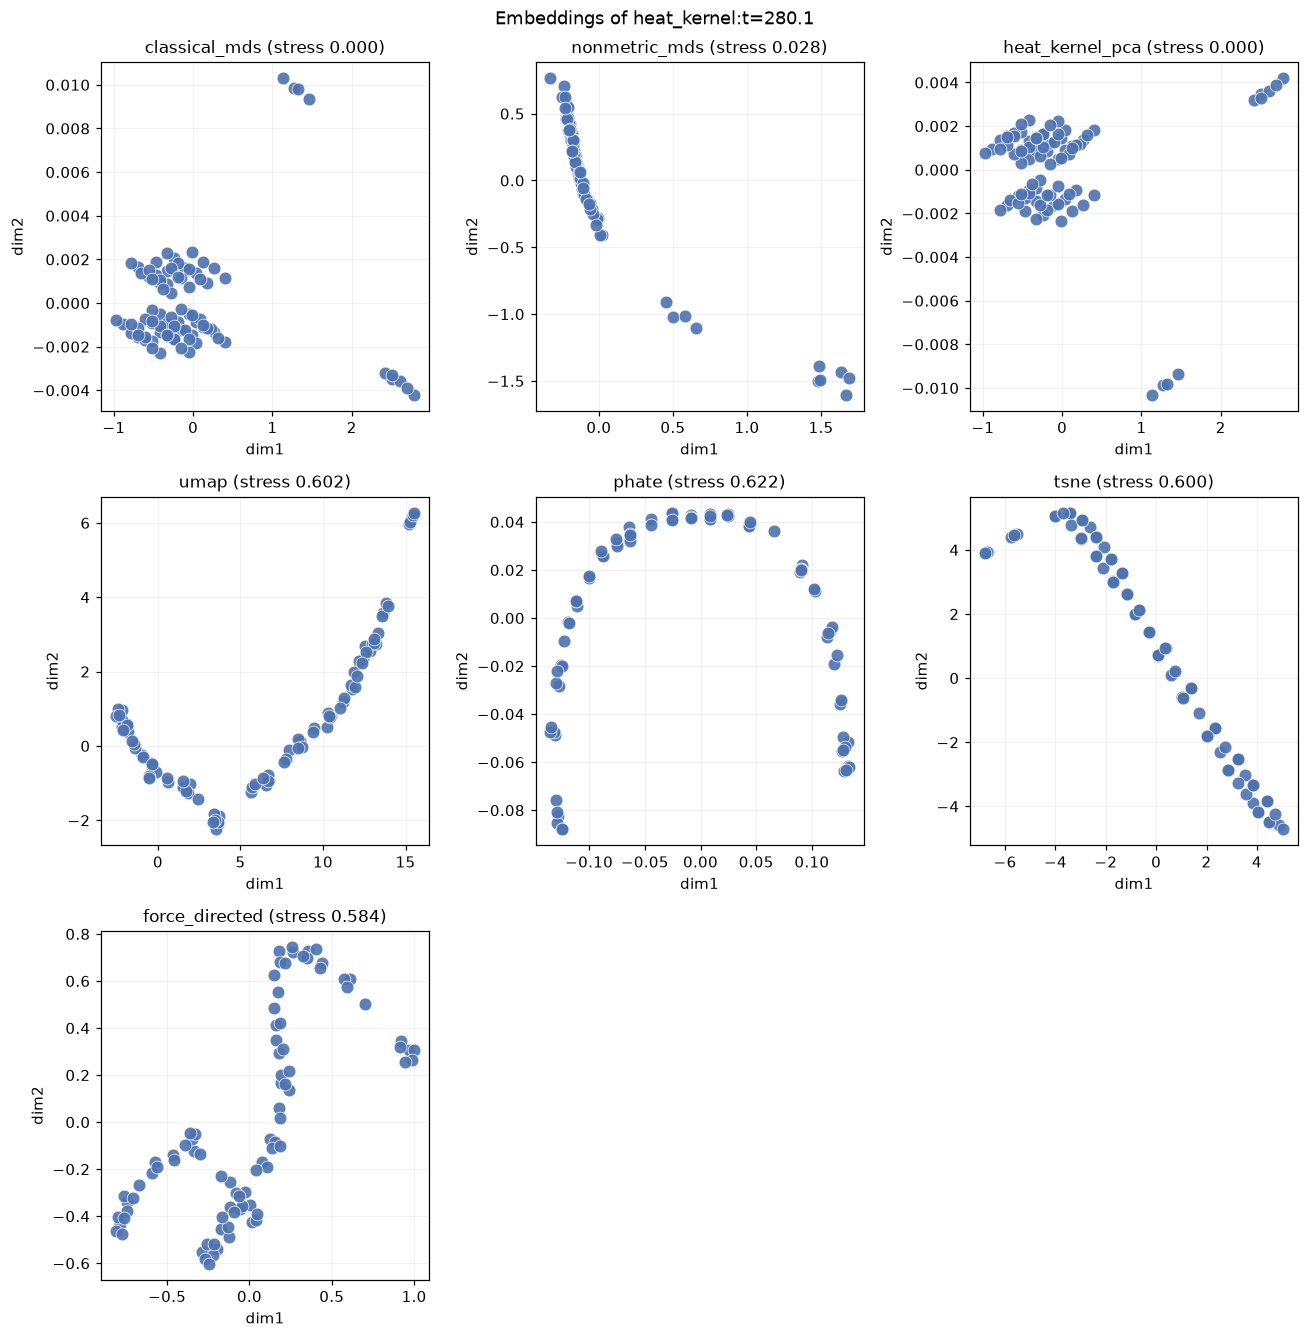

In [12]:
figure, _ = valley.plot_embedding_grid(
    embeddings,
    ncols=3,
    scores=result["scores"],
    labels=labels,
    dot_size=70,
)
figure.suptitle(f"Embeddings of {key}", y=1.01)

## Step 5 - PHATE across distance definitions

Hold PHATE fixed while changing its precomputed input distance. Each projection is scored against
the distance matrix that produced it, allowing fidelity and neighbourhood preservation to be
compared across the distance definitions.

In [13]:
phate_embeddings = {}
phate_score_rows = []

for distance_name, distance_matrix in matrices.items():
    comparison = valley.compare_embeddings(
        distance_matrix,
        n_components=2,
        labels=labels,
        include=("phate",),
        random_state=SEED,
    )
    if "phate" not in comparison["embeddings"]:
        continue

    phate_embeddings[distance_name] = comparison["embeddings"]["phate"]
    score = comparison["scores"].loc["phate"].to_dict()
    score["distance"] = distance_name
    phate_score_rows.append(score)

if not phate_score_rows:
    raise RuntimeError("PHATE was not built; install the optional 'phate' dependency.")

phate_scores = (
    pd.DataFrame(phate_score_rows)
    .set_index("distance")
    .sort_values("stress")
)
print(f"PHATE built for {len(phate_embeddings)} distance definitions")
phate_scores.round(3)

    SGD-MDS may not have converged: stress changed by 5.0% in final iterations. Consider increasing n_iter or adjusting learning_rate.
[skip] silhouette:phate -> Number of labels is 88. Valid values are 2 to n_samples - 1 (inclusive)
[skip] silhouette:phate -> Number of labels is 88. Valid values are 2 to n_samples - 1 (inclusive)
    SGD-MDS may not have converged: stress changed by 6.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.
[skip] silhouette:phate -> Number of labels is 88. Valid values are 2 to n_samples - 1 (inclusive)
    SGD-MDS may not have converged: stress changed by 2.0% in final iterations. Consider increasing n_iter or adjusting learning_rate.


/Users/saran/.local/lib/python3.12/site-packages/phate/phate.py:919: RuntimeWarning: Graph is disconnected with 8 connected components. This may indicate that your knn parameter (currently 5) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(
/Users/saran/.local/lib/python3.12/site-packages/phate/phate.py:919: RuntimeWarning: Graph is disconnected with 10 connected components. This may indicate that your knn parameter (currently 5) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(
/Users/saran/.local/lib/python3.12/site-packages/phate/phate.py:919: RuntimeWarning: Graph is disconnected with 10 connected components. This may indicate that your knn parameter (currently 5) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relations

[skip] silhouette:phate -> Number of labels is 88. Valid values are 2 to n_samples - 1 (inclusive)
[skip] silhouette:phate -> Number of labels is 88. Valid values are 2 to n_samples - 1 (inclusive)
[skip] silhouette:phate -> Number of labels is 88. Valid values are 2 to n_samples - 1 (inclusive)
[skip] silhouette:phate -> Number of labels is 88. Valid values are 2 to n_samples - 1 (inclusive)
[skip] silhouette:phate -> Number of labels is 88. Valid values are 2 to n_samples - 1 (inclusive)
[skip] silhouette:phate -> Number of labels is 88. Valid values are 2 to n_samples - 1 (inclusive)

/Users/saran/.local/lib/python3.12/site-packages/phate/phate.py:919: RuntimeWarning: Graph is disconnected with 6 connected components. This may indicate that your knn parameter (currently 5) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(
/Users/saran/.local/lib/python3.12/site-packages/phate/phate.py:919: RuntimeWarning: Graph is disconnected with 6 connected components. This may indicate that your knn parameter (currently 5) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(
/Users/saran/.local/lib/python3.12/site-packages/phate/phate.py:919: RuntimeWarning: Graph is disconnected with 5 connected components. This may indicate that your knn parameter (currently 5) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationshi


[skip] silhouette:phate -> Number of labels is 88. Valid values are 2 to n_samples - 1 (inclusive)
    SGD-MDS may not have converged: stress changed by 2.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.
[skip] silhouette:phate -> Number of labels is 88. Valid values are 2 to n_samples - 1 (inclusive)
    SGD-MDS may not have converged: stress changed by 8.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.
[skip] silhouette:phate -> Number of labels is 88. Valid values are 2 to n_samples - 1 (inclusive)
    SGD-MDS may not have converged: stress changed by -3.2% in final iterations. Consider increasing n_iter or adjusting learning_rate.
[skip] silhouette:phate -> Number of labels is 88. Valid values are 2 to n_samples - 1 (inclusive)
    SGD-MDS may not have converged: stress changed by -3.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.
[skip] silhouette:phate -> Number of labels is 88. Valid valu

/Users/saran/.local/lib/python3.12/site-packages/phate/phate.py:919: RuntimeWarning: Graph is disconnected with 6 connected components. This may indicate that your knn parameter (currently 5) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(
/Users/saran/.local/lib/python3.12/site-packages/phate/phate.py:919: RuntimeWarning: Graph is disconnected with 2 connected components. This may indicate that your knn parameter (currently 5) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(


,n_components,deterministic,stress,spearman_vs_distance,trustworthiness,silhouette
distance,,,,,,
heat_kernel:t=0.1528,2,False,0.443,0.466,0.936,NaN
heat_kernel:t=3.086,2,False,0.449,0.505,0.916,NaN
heat_kernel:t=0.03399,2,False,0.458,0.321,0.961,NaN
heat_kernel:t=0.007563,2,False,0.458,0.319,0.959,NaN
heat_kernel:t=0.001683,2,False,0.458,0.318,0.959,NaN
heat_kernel:t=0.6866,2,False,0.460,0.456,0.922,NaN
module_scc,2,False,0.464,0.386,0.926,NaN
reference_axis,2,False,0.468,0.880,0.993,NaN
heat_kernel:t=13.87,2,False,0.491,0.485,0.952,NaN


Text(0.5, 1.01, 'PHATE embeddings across distance definitions')

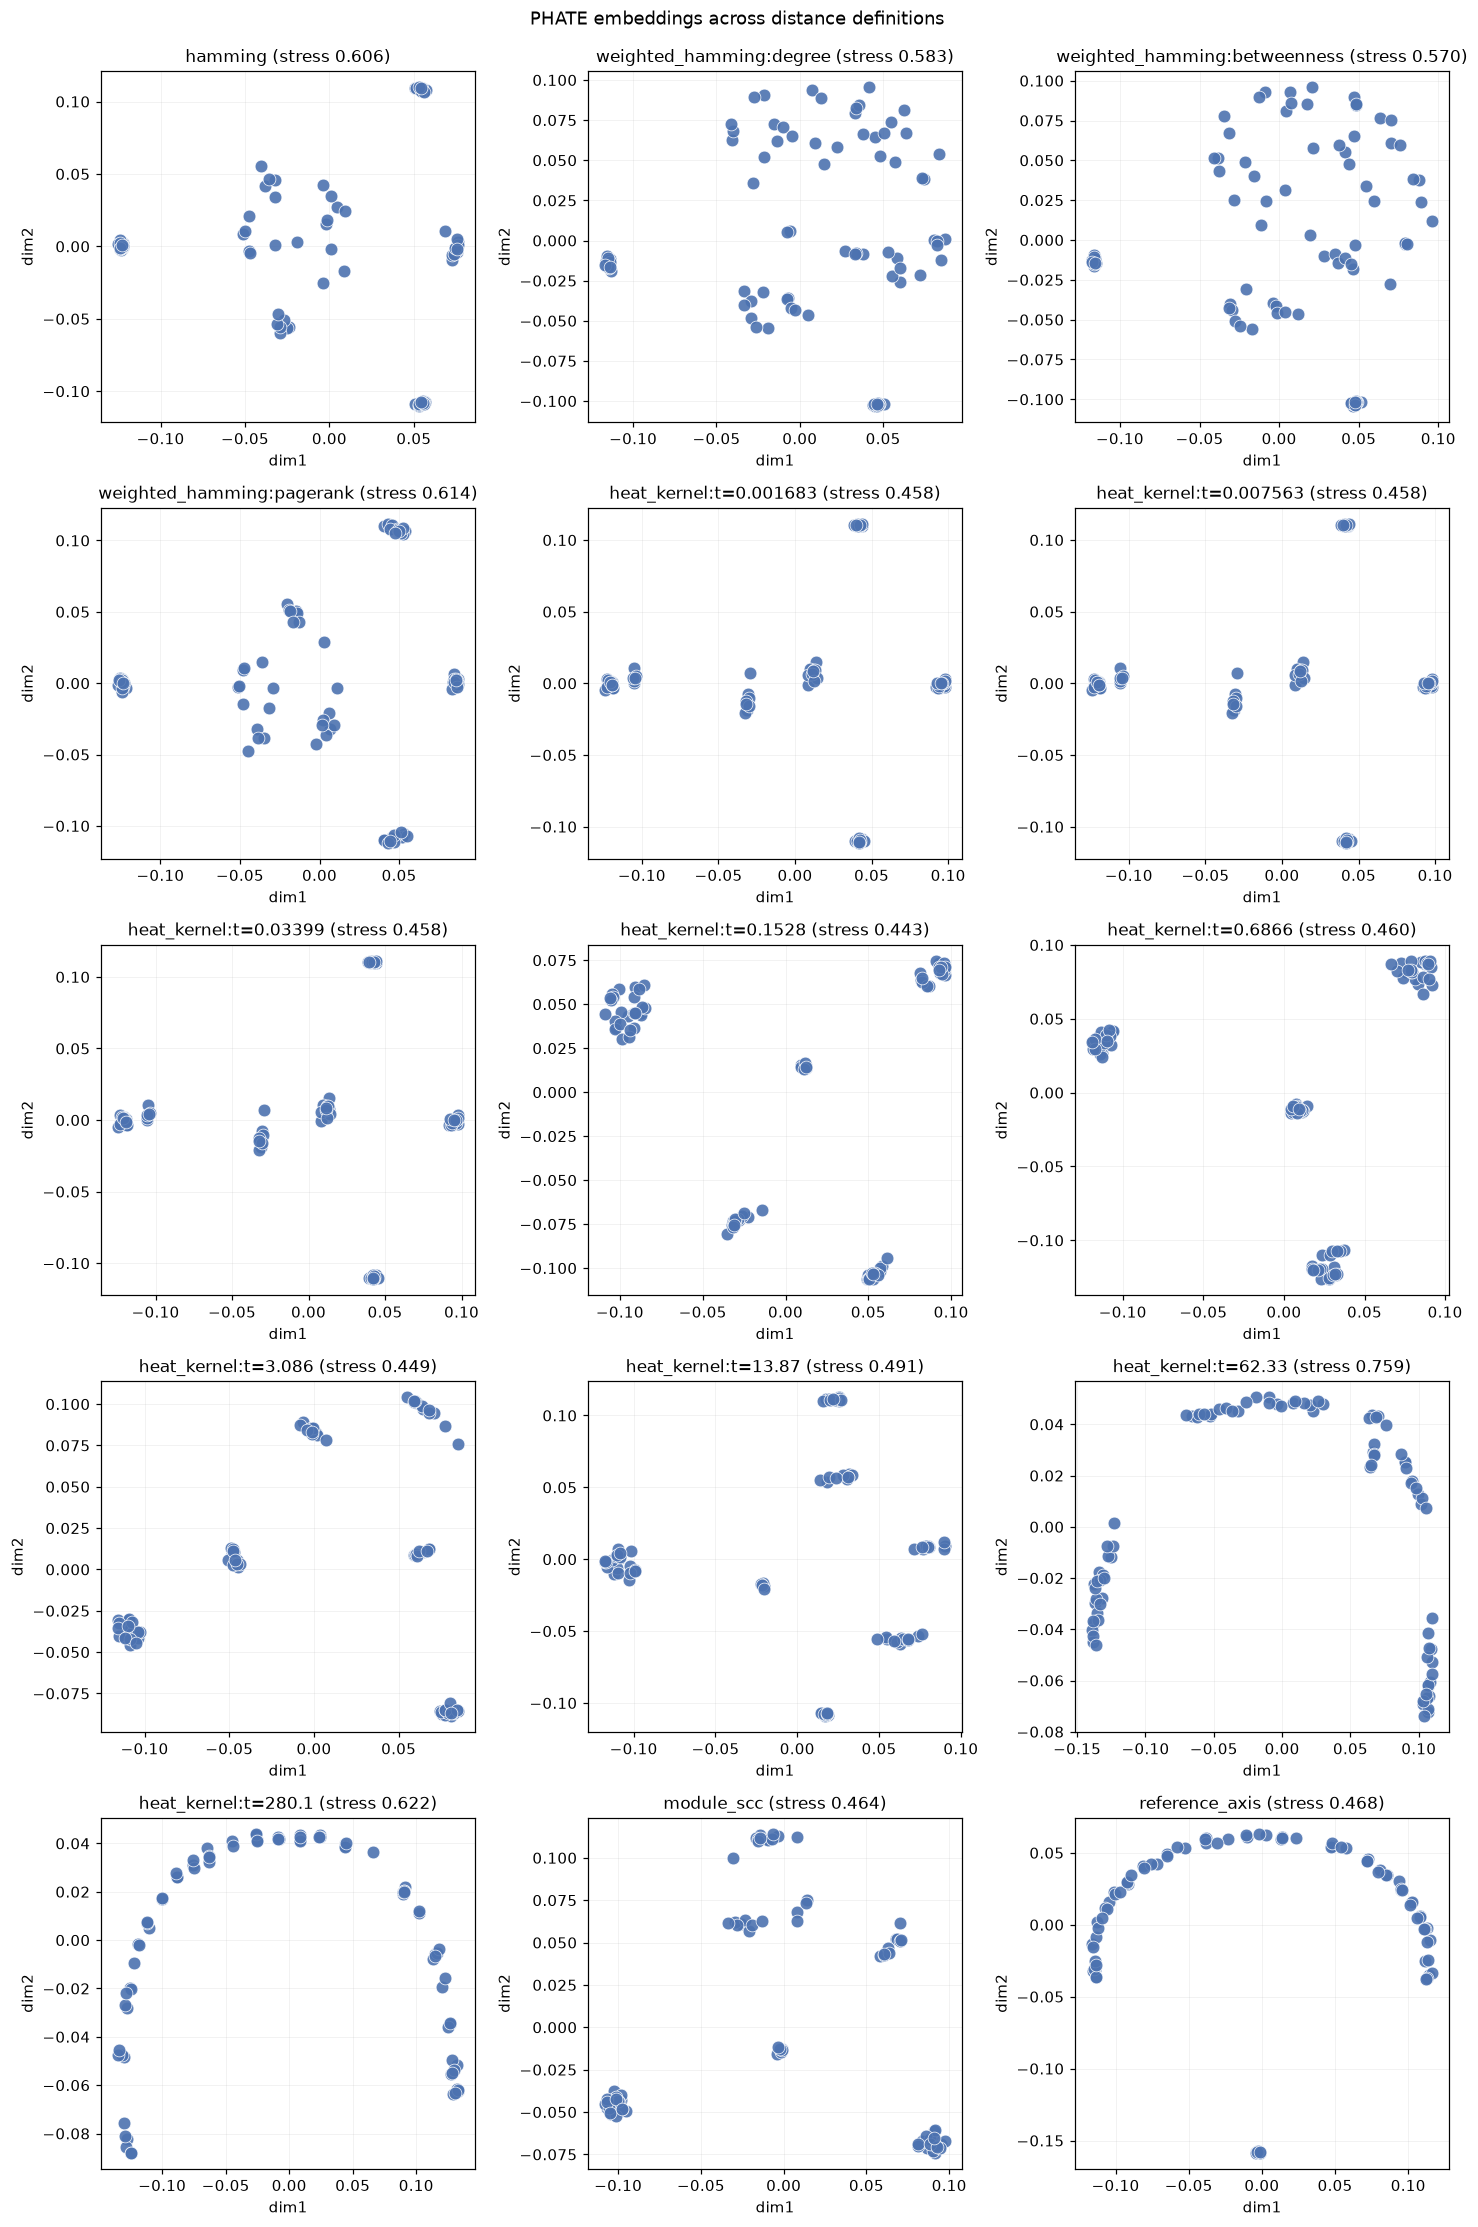

In [15]:
figure, _ = valley.plot_embedding_grid(
    phate_embeddings,
    ncols=3,
    scores=phate_scores,
    labels=labels,
    dot_size=70,
    panel_size=(4.5, 4.0),
)
figure.suptitle("PHATE embeddings across distance definitions", y=1.01)

In [64]:
D = matrices['heat_kernel:t=3.086']
Z = valley.diffusion_features(S, geometry, t = 3.086)

GraphGeometry(W=array([[0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0.5],
       [0. , 0. , 0. , ..., 0. , 0.5, 0. ]], shape=(119, 119)), kind='combinatorial')

## 5. Attractor clustering

The distance matrix answers *how far apart* two attractors are; clustering
answers *how many phenotype groups there are*. Everything in this section is
computed on `D` (or on `Z`, which is isometric to it), never on the 2D
coordinates.

Order of the sub-steps, each one a decision that has to be stated in a caption:

- **5a** how many clusters, and with which method
- **5b** the chosen partition, with one real attractor per cluster as its medoid
- **5c** is the partition a property of the model, or of one diffusion scale?
- **5d** are the clusters carried by many nodes or by a lucky few?
- **5e** what are the clusters, biologically
- **5f** the figures: clusters in the embedding, and cluster profiles on the network

### 5a. How many clusters, and which method

`choose_k` gives the silhouette curve, not just its argmax: a flat curve means
the number of groups is not determined by the data and must be reported as a
range. `build_clusterings` runs every applicable method; Ward and k-means are
attempted only when `features=Z` is available, because they need genuine
Euclidean geometry and only the heat-kernel distance provides it exactly.

If a curated phenotype annotation or the biobalm trap-space grouping is
available, pass it as `reference_labels`: agreement validates the metric,
disagreement is the result that needs an explanation.

 k  silhouette  within_over_between
 2       0.494                0.503
 3       0.483                0.504
 4       0.390                0.533
 5       0.373                0.511
 6       0.405                0.457
 7       0.396                0.441
 8       0.392                0.408

working k = 2


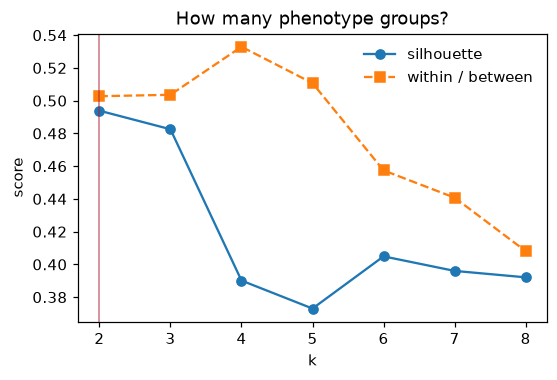

In [82]:
k_curve = valley.choose_k(D, method="average", k_values=range(2, min(9, len(labels))))
print(k_curve.round(3).to_string(index=False))

if not k_curve.empty:
    K = int(k_curve.sort_values("silhouette", ascending=False).iloc[0]["k"])
    print(f"\nworking k = {K}")

    fig, ax = plt.subplots(figsize=(5.5, 3.4))
    ax.plot(k_curve["k"], k_curve["silhouette"], marker="o", label="silhouette")
    ax.plot(
        k_curve["k"],
        k_curve["within_over_between"],
        marker="s",
        linestyle="--",
        label="within / between",
    )
    ax.axvline(K, color="#b2182b", linewidth=1.0, alpha=0.6)
    ax.set_xlabel("k")
    ax.set_ylabel("score")
    ax.set_title("How many phenotype groups?")
    ax.legend(frameon=False)

In [83]:
# reference_labels = attractors["phenotype"]  # curated, or the biobalm grouping
candidates = valley.build_clusterings(
    D, k=K, features=Z, weights=None, random_state=SEED
)
scores = valley.score_clusterings(candidates, D)
print(scores.round(3).to_string())
print(
    "\nEuclidean-only methods"
    + (" included (exact feature map)" if Z is not None else " skipped: no feature map")
)

             k  n_noise  silhouette  within_over_between
clustering                                              
average      2        0       0.494                0.503
complete     2        0       0.494                0.503
ward         2        0       0.494                0.503
kmeans       2        0       0.494                0.503
single       2        0       0.493                0.519
spectral     2        0       0.493                0.519
hdbscan     10        0       0.408                0.374
affinity    14        0       0.372                0.340
kmedoids     2        0       0.280                0.731

Euclidean-only methods included (exact feature map)


/Users/saran/miniconda3/envs/valley/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [100]:
clustering = valley.cluster_attractors(D, method="average", k=6, weights=None)
flat = valley.cluster_attractors(D, method="kmedoids", k=6, weights=None, random_state=SEED)

print(f"average linkage: k={clustering.k}, noise={clustering.n_noise}")
print(f"k-medoids      : k={flat.k}, cost={flat.info.get('cost')}")
print(f"\nmedoid attractors: {attractors.index[clustering.medoids].tolist()}")

sizes = clustering.to_series(labels=attractors.index).value_counts().sort_index()
print("\ncluster sizes")
print(sizes.to_string())

from sklearn.metrics import adjusted_rand_score

print(f"\nARI linkage vs k-medoids: {adjusted_rand_score(clustering.labels, flat.labels):.3f}")

average linkage: k=6, noise=0
k-medoids      : k=6, cost=118.81757294676936

medoid attractors: [80, 108, 88, 116, 67, 74]

cluster sizes
cluster
0    12
1    24
2    18
3    24
4     4
5     6

ARI linkage vs k-medoids: 1.000


      t  ari_vs_consensus  ari_vs_smallest_t
  0.002               1.0                1.0
  0.008               1.0                1.0
  0.034               1.0                1.0
  0.153               1.0                1.0
  0.687               1.0                1.0
  3.086               1.0                1.0
 13.868               1.0                1.0
 62.327               1.0                1.0
280.121               1.0                1.0

co-association: 20% of pairs never co-cluster, 80% always, 0% ambiguous


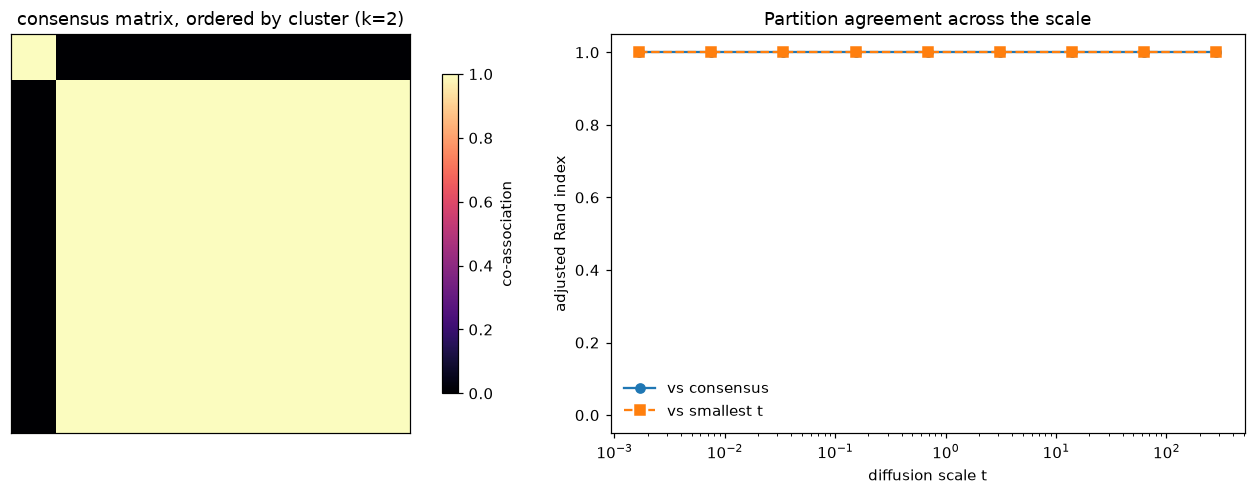

In [101]:
consensus = valley.consensus_clustering(attractors, model, t_values=t_values, k=K)
C = consensus["consensus"]
print(consensus["stability"].round(3).to_string(index=False))

off = C[~np.eye(C.shape[0], dtype=bool)]
print(f"\nco-association: {float((off < 0.1).mean()):.0%} of pairs never co-cluster, "
      f"{float((off > 0.9).mean()):.0%} always, {float(((off >= 0.1) & (off <= 0.9)).mean()):.0%} ambiguous")

order = np.argsort(consensus["clustering"].labels)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
im = axes[0].imshow(C[np.ix_(order, order)], cmap="magma", vmin=0, vmax=1)
axes[0].set_title(f"consensus matrix, ordered by cluster (k={K})")
axes[0].set_xticks([])
axes[0].set_yticks([])
fig.colorbar(im, ax=axes[0], shrink=0.8, label="co-association")

stability = consensus["stability"]
axes[1].plot(stability["t"], stability["ari_vs_consensus"], marker="o", label="vs consensus")
axes[1].plot(
    stability["t"],
    stability["ari_vs_smallest_t"],
    marker="s",
    linestyle="--",
    label="vs smallest t",
)
axes[1].set_xscale("log")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xlabel("diffusion scale t")
axes[1].set_ylabel("adjusted Rand index")
axes[1].set_title("Partition agreement across the scale")
axes[1].legend(frameon=False)
figure = fig
fig.tight_layout()

         n_attractors      mass                                                                                             on                                                                                       off
cluster                                                                                                                                                                                                                 
0                  12  0.136364    ROMO1 (+0.60), mRNA_ROMO1 (+0.60), CHOP_sustained (+0.40), EIF2AK3 (+0.40), BCL2L11 (+0.40)                         RAS (-0.60), GRB2 (-0.60), GAB (-0.60), EGFR (-0.60), RAF (-0.60)
1                  24  0.272727          AA_Starvation (+0.80), Tubulin (+0.80), JIP (+0.80), Kinesin_1 (+0.80), ROMO1 (+0.60)               RRAGA (-0.80), GAB (-0.60), SOS (-0.60), Growth_factor (-0.60), RAS (-0.60)
2                  18  0.204545                               RAF (+0.60), GAB (+0.60), RAS (+0.60), EGFR (+0.60), SOS (+0.60)  mRNA

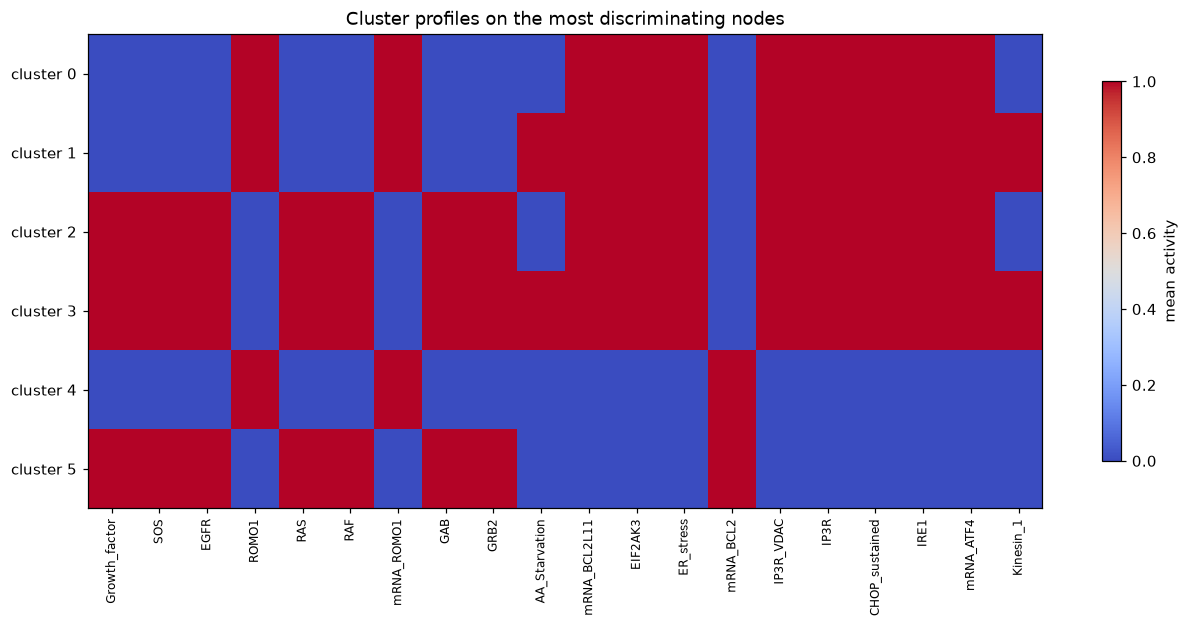

In [102]:
profiles = valley.cluster_activity(attractors, clustering.labels, weights=None)
signatures = valley.cluster_signatures(attractors, clustering.labels, top=5, weights=None)

print(signatures.to_string())
print("\nmost discriminating nodes overall")
print(signatures.attrs["between_cluster_spread"].head(10).round(3).to_string())

discriminating = signatures.attrs["between_cluster_spread"].head(20).index
fig, ax = plt.subplots(figsize=(min(14, 0.55 * len(discriminating) + 3), 0.6 * len(profiles) + 2))
im = ax.imshow(profiles[discriminating].to_numpy(), cmap="coolwarm", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(discriminating)))
ax.set_xticklabels(discriminating, rotation=90, fontsize=8)
ax.set_yticks(range(len(profiles)))
ax.set_yticklabels([f"cluster {i}" for i in profiles.index])
ax.set_title("Cluster profiles on the most discriminating nodes")
fig.colorbar(im, ax=ax, shrink=0.8, label="mean activity")

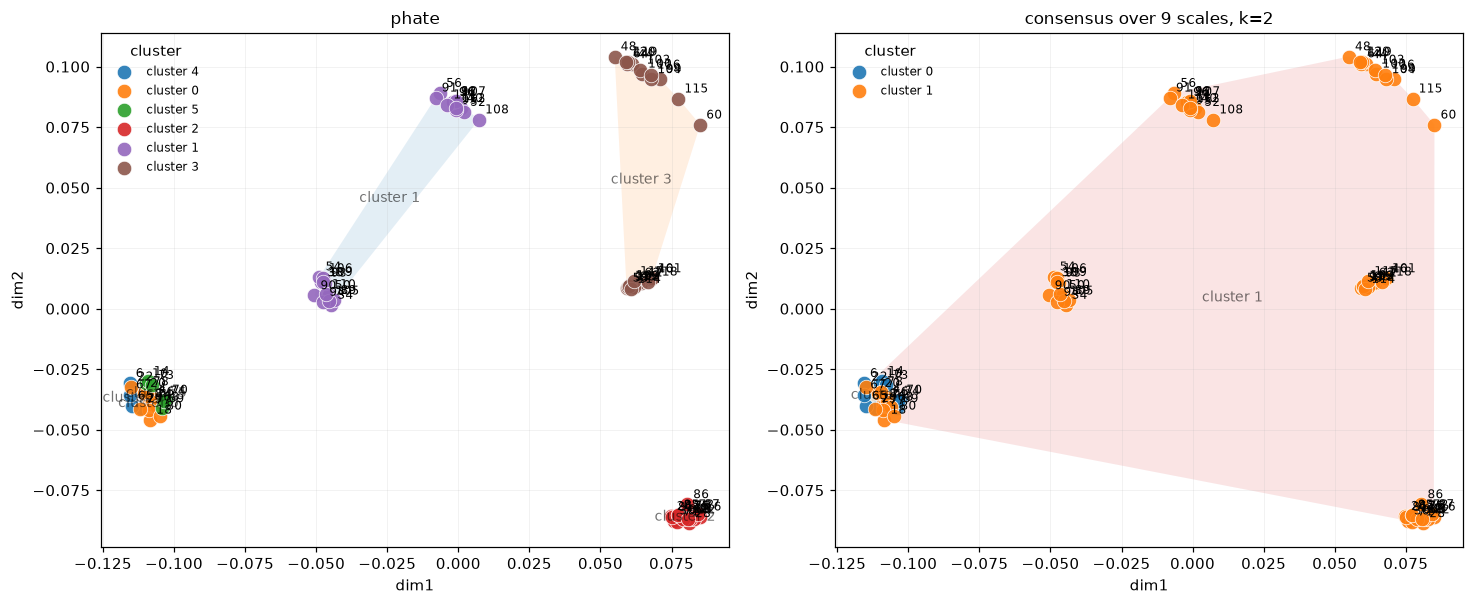

In [103]:
test = phate_embeddings['heat_kernel:t=3.086']
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
valley.plot_embedding(
    test,
    labels=labels,
    clusters=clustering.labels,
    ax=axes[0],
    annotate=True,
    dot_size=90,
    #title=f"{name}: average linkage, k={K}",
)
valley.plot_embedding(
    test,
    labels=labels,
    clusters=consensus["clustering"].labels,
    ax=axes[1],
    annotate=True,
    dot_size=90,
    title=f"consensus over {len(consensus['per_scale'])} scales, k={K}",
)
fig.tight_layout()

Text(0.5, 1.01, 'Mean activity per cluster')

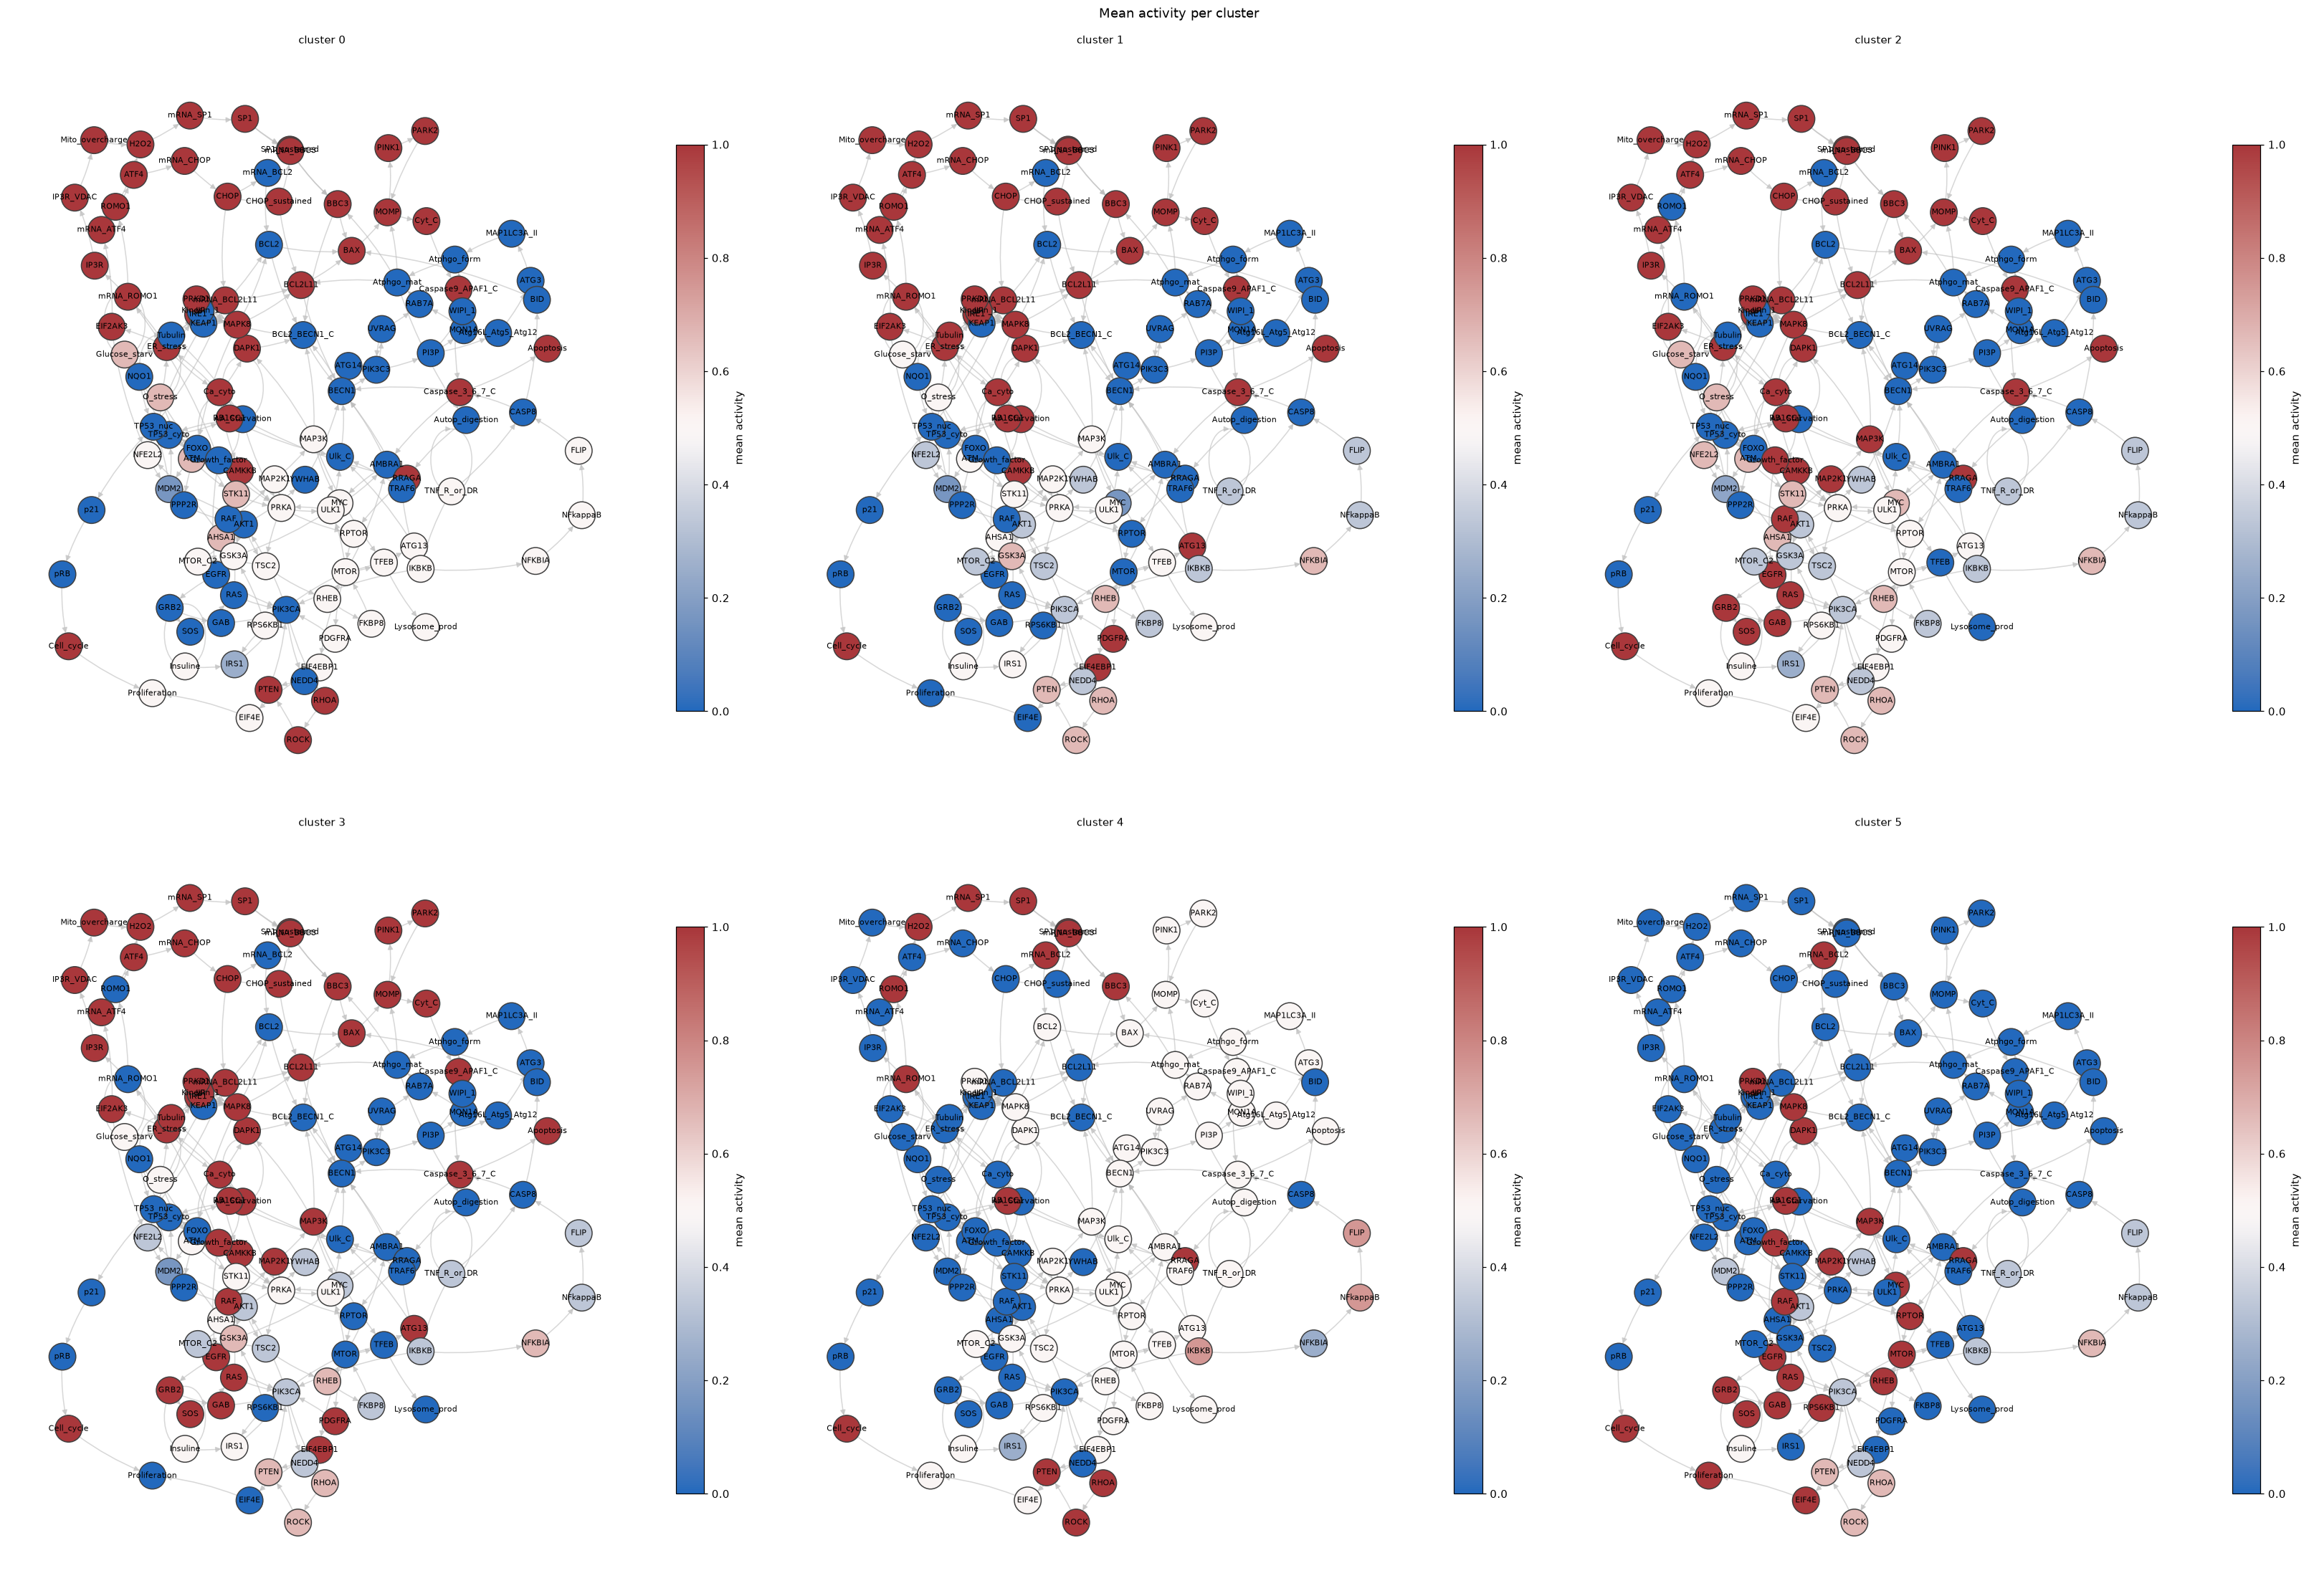

In [104]:
groups = valley.cluster_groups(attractors, clustering.labels, drop_noise=True)
fig, _ = valley.plot_attractor_panels(
    groups,
    model,
    ncols=min(3, len(groups)),
    positions=positions,
    cmap = 'vlag',
    node_size=600,
    font_size=7,
    panel_size = (10, 10),
    weights=None,  # per-panel weighting would need per-cluster probabilities
)
fig.suptitle("Mean activity per cluster", y=1.01)

In [97]:
from __future__ import annotations

from typing import Mapping, Sequence

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import networkx as nx
import numpy as np
import pandas as pd


def terminal_cluster_labels(
    diagram: nx.DiGraph,
    attractors: pd.DataFrame,
    clusters: Sequence[int],
) -> pd.DataFrame:
    """Match each terminal node's fixed state to compatible attractors.

    The succession diagram stores fixed variables in each node's ``space``
    attribute.  Attractor entries equal to 0.5 are wildcards and therefore
    match either fixed value.  A terminal is assigned a cluster only when all
    matching attractors have the same label.
    """
    labels = np.asarray(clusters)
    if len(labels) != len(attractors):
        raise ValueError("clusters must contain one label per attractor")

    states = attractors.copy()
    states.columns = states.columns.map(str)
    records = []

    for node, data in diagram.nodes(data=True):
        if diagram.out_degree(node) != 0:
            continue

        space: Mapping[str, object] = data.get("space", {})
        matches = np.ones(len(states), dtype=bool)
        for variable, value in space.items():
            variable = str(variable)
            if variable not in states:
                matches &= False
                break
            activity = states[variable].to_numpy(dtype=float)
            fixed_value = float(value)
            matches &= np.isclose(activity, fixed_value) | np.isclose(activity, 0.5)

        matched_labels = np.unique(labels[matches])
        cluster = int(matched_labels[0]) if len(matched_labels) == 1 else None
        records.append(
            {
                "node": node,
                "cluster": cluster,
                "n_matches": int(matches.sum()),
                "status": (
                    "assigned"
                    if cluster is not None
                    else "unmatched"
                    if not matches.any()
                    else "mixed"
                ),
            }
        )

    return pd.DataFrame.from_records(records).set_index("node")


def plot_succession_clusters(
    diagram: nx.DiGraph,
    attractors: pd.DataFrame,
    clusters: Sequence[int],
    *,
    ax: plt.Axes | None = None,
    pos: Mapping | None = None,
    cmap: str = "tab10",
    seed: int = 42,
) -> tuple[plt.Axes, pd.DataFrame]:
    """Draw a succession diagram with terminal nodes filled by cluster.

    Returns the axes and a terminal-node mapping table with ``cluster``,
    ``n_matches``, and ``status`` columns.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(14, 10))
    if pos is None:
        pos = nx.kamada_kawai_layout(diagram)

    mapping = terminal_cluster_labels(diagram, attractors, clusters)
    terminal_nodes = set(mapping.index)
    assigned = mapping[mapping["status"] == "assigned"]
    cluster_ids = sorted(assigned["cluster"].unique())
    colour_map = plt.get_cmap(cmap)
    cluster_colours = {
        cluster: colour_map(index % colour_map.N)
        for index, cluster in enumerate(cluster_ids)
    }

    node_colours = []
    for node in diagram.nodes:
        if node not in terminal_nodes:
            node_colours.append("#d9d9d9")
        elif mapping.loc[node, "status"] == "assigned":
            node_colours.append(cluster_colours[mapping.loc[node, "cluster"]])
        elif mapping.loc[node, "status"] == "mixed":
            node_colours.append("#fdae61")
        else:
            node_colours.append("#ffffff")

    nx.draw_networkx(
        diagram,
        pos=pos,
        ax=ax,
        with_labels=True,
        node_color=node_colours,
        node_size=700,
        font_size=8,
        arrows=True,
        edgecolors="#4d4d4d",
        linewidths=0.7,
    )
    legend = [
        Patch(facecolor=cluster_colours[cluster], edgecolor="#4d4d4d", label=f"cluster {cluster}")
        for cluster in cluster_ids
    ]
    if (mapping["status"] == "mixed").any():
        legend.append(Patch(facecolor="#fdae61", edgecolor="#4d4d4d", label="mixed clusters"))
    if (mapping["status"] == "unmatched").any():
        legend.append(Patch(facecolor="#ffffff", edgecolor="#4d4d4d", label="unmatched"))
    if legend:
        ax.legend(handles=legend, title="terminal attractors", loc="best")
    ax.set_axis_off()
    return ax, mapping

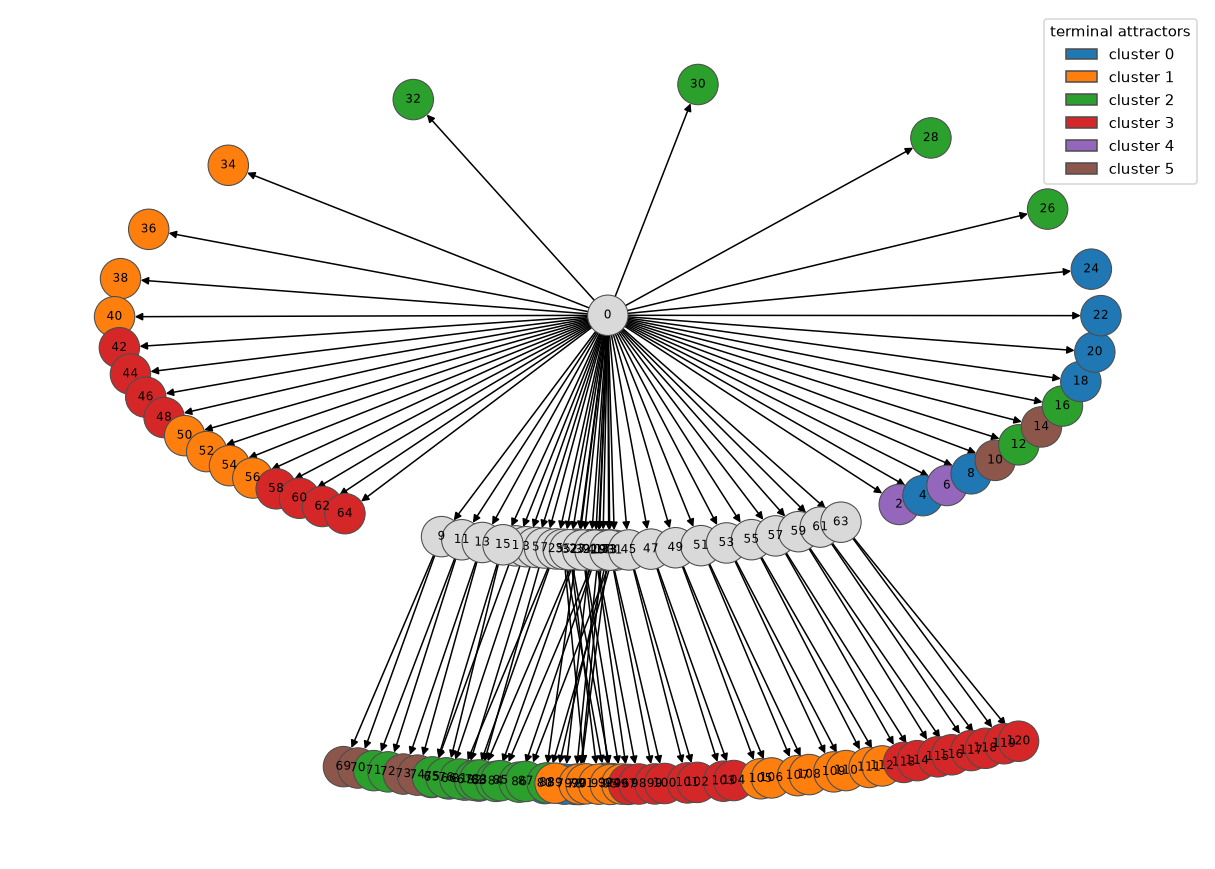

In [105]:
ax, terminal_mapping = plot_succession_clusters(
    G,
    attractors,
    clustering.labels,
)
plt.show()